# Event-Based Camera Processing - Part 1: 

**Attribution & Credits**
This notebook series is inspired by and extends the excellent **AMOS Short Course** by the
*International Centre for Neuromorphic Systems (ICNS), Western Sydney University* (2023).
Original tutorials: https://github.com/gcohen/AMOS-Short-Course
The original tutorials were prepared by the ICNS team for the AMOS Conference 2023.

We extend their Tutorials 1-3 with more explanations, new experiments, and context
connecting to our broader study of Spiking Neural Networks and event-based cameras.

---

**What you will learn in this notebook (Part 1)**
1. `tonic` vs `event_stream` - what each library does and how to use them together
2. Tools and tips for visualising and working with event-based data
3. Multiple experiments on generating frames from event streams

You need the AMOS data files in `../AMOS-Short-Course-main/Data/WSU/`.


## 1. Library Setup

We use two complementary libraries throughout this series.
Run the cell below once to install any missing packages.


In [1]:
# Run this once if needed
%pip install event_stream tonic matplotlib numpy torch


Note: you may need to restart the kernel to use updated packages.


In [1]:
# Core imports - confirm everything loads
import event_stream      # for .es files (the AMOS format)
import tonic             # for curated neuromorphic datasets (N-MNIST, N-Caltech, etc.)
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation
from IPython.display import HTML

print(f"event_stream: OK")
print(f"tonic version: {tonic.__version__}")
print(f"numpy version: {np.__version__}")


event_stream: OK
tonic version: 1.6.0
numpy version: 1.26.4


---
## 2. event_stream

The **`event_stream`**  library uses the concepts of encoders and decoders to work with event-based files.

**Decoders** interpret files(raw binary data)that event cameras generate, and produce a stream of events for processing, whilst **encoders** write new event-based data to a data file(packed binary format).

Unlike frame-based sensors that sample the entire pixel array at a fixed frequency ($Hz$), event-based data is asynchronous. Each pixel acts as an independent processor, generating an event only when the intensity of the pixel changes. This results in a sparse, continuous stream of data where the data rate is proportional to the scene's dynamics rather than a clock.

The most common decoder type (and the one used throughout these tutorials) is the dvs data type.

In practice, reading the data event-by-event from the file is inefficient as it incurs a significant overhead on each event. For performance reasons, we tend to buffer the data into groups of events. The event_stream decoder implements this by reading in chunks of events and then allowing you to iterate through them.

---
## 3. Tonic vs event_stream 


| Feature | `event_stream` | `tonic` |
|---|---|---|
| **Purpose** | Read/write raw `.es` files from real cameras | Load curated benchmark datasets + transforms |
| **Data format** | Structured numpy array from a file you captured | Same structured numpy array, but downloaded for use |
| **Use case** | Working with own camera data | Experimenting with standard benchmarks (N-MNIST, N-Caltech...) |
| **Transforms** | Manual (you write the code) | Rich library of transforms (ToFrame, TimeSurface, etc.) |
| **File formats** | `.es` (Event Stream format) | Many formats via internal decoders |


- **`tonic`** is to event-based cameras what **`torchvision`** is to conventional vision.
  It gives you clean benchmark datasets and a pipeline of standard transforms. Perfect for
  research and for learning, because the messy data-loading work is already done.

- **`event_stream`** is what you use when you have a real camera in your hands
  (a DAVIS346, a Prophesee Gen4, etc.) and you want to read back recordings you made.
  It is lower-level and closer to the raw hardware.

**In practice you often use both**: prototype and benchmark with `tonic`, then port your
algorithm to `event_stream` when you deploy on real camera data.  The event data structure
`(x, y, t, p)` is identical in both.

### event dtype

Both libraries return events as numpy structured arrays. The field names differ slightly:

```
event_stream: fields are  't', 'x', 'y', 'p'   
tonic:        fields are  'x', 'y', 't', 'p'   
```

This means a helper function that renames fields lets you pass data between them seamlessly.


In [2]:
# ------------------------------------------------------------------
# Demonstrating the dtype difference between event_stream and tonic
# ------------------------------------------------------------------

DATA_DIR = r"C:\Users\sampr\OneDrive\Desktop\Spiking Neural Networks\AMOS-Short-Course-main\Data\WSU"

# --- Load the same recording with event_stream ---
decoder_es = event_stream.Decoder(f"{DATA_DIR}/strange_horse.es")
events_es  = np.concatenate(list(decoder_es))

print("event_stream dtype fields:", events_es.dtype.names)
print("First event:", events_es[0])

# --- Load N-MNIST (a tonic dataset) and look at the dtype ---
import tonic
dataset = tonic.datasets.NMNIST(save_to='./data', train=True)
events_tonic, label = dataset[0]

print("\ntonic dtype fields:      ", events_tonic.dtype.names)
print("First event:", events_tonic[0])


event_stream dtype fields: ('t', 'x', 'y', 'p')
First event: (4000012, 545, 715, True)

tonic dtype fields:       ('x', 'y', 't', 'p')
First event: (10, 30, 937, 1)


In [3]:
# ------------------------------------------------------------------
# Helper function: make event_stream events look like tonic events
#   1. Polarity field: older event_stream used 'on', newer versions use 'p'.
#      We detect which is present at runtime.
#   2. Timestamp dtype was '<i4' (int32), which OVERFLOWS at ~35 min recordings.
#      Now uses '<i8' (int64).
# ------------------------------------------------------------------

# WHY the dtypes look different:
#   event_stream: ('t', 'x', 'y', 'p')  — t is first, polarity may be bool
#   tonic:        ('x', 'y', 't', 'p')  — x is first, polarity is int 0/1
#
# The ORDER only affects how tuples PRINT.
# Named access  (events['x'], events['t'])  works correctly regardless of order.
# The function below is safe because it always uses NAMED field access.

def es_to_tonic_format(events_es, sensor_size_tuple):
    """
    Convert event_stream structured array to tonic-compatible structured array.

    Handles both old event_stream (polarity field = 'on')
    and new event_stream (polarity field = 'p').

    sensor_size_tuple : (width, height, n_polarities)
    """
    # Detect polarity field name - old versions used 'on', new use 'p'
    if 'on' in events_es.dtype.names:
        polarity_raw = events_es['on']
    elif 'p' in events_es.dtype.names:
        polarity_raw = events_es['p']
    else:
        raise ValueError(f"Cannot find polarity field. Fields found: {events_es.dtype.names}")

    # Use int64 for timestamps — int32 overflows at ~2.1 billion us = only ~35 minutes!
    new_dtype = np.dtype([
        ('x', '<i4'),
        ('y', '<i4'),
        ('t', '<i8'),   # i8 = int64, not i4 = int32 — critical for long recordings
        ('p', '<i4'),
    ])

    new_events = np.zeros(len(events_es), dtype=new_dtype)
    new_events['x'] = events_es['x']
    new_events['y'] = events_es['y']
    new_events['t'] = events_es['t']
    new_events['p'] = polarity_raw.astype(np.int32)   # True -> 1, False -> 0

    # Sanity check: coordinates should be within sensor bounds
    W, H, _ = sensor_size_tuple
    if new_events['x'].max() >= W or new_events['y'].max() >= H:
        print(f"WARNING: events outside sensor bounds ({W}x{H}). Check your data file.")

    return new_events


sensor_size = (decoder_es.width, decoder_es.height, 2)
events_tonic_format = es_to_tonic_format(events_es, sensor_size)

print('event_stream raw dtype :', events_es.dtype.names)
print('Converted tonic dtype  :', events_tonic_format.dtype.names)
print()
print('Raw first event   :', events_es[0])
print('Tonic first event :', events_tonic_format[0])
print()
# Verify the VALUES match (only field names and order changed)
assert events_tonic_format['x'][0] == events_es['x'][0]
assert events_tonic_format['y'][0] == events_es['y'][0]
assert int(events_tonic_format['t'][0]) == int(events_es['t'][0])
print('All field values match -- conversion is correct')
print(f'Sensor size (W x H x P): {sensor_size}')


event_stream raw dtype : ('t', 'x', 'y', 'p')
Converted tonic dtype  : ('x', 'y', 't', 'p')

Raw first event   : (4000012, 545, 715, True)
Tonic first event : (545, 715, 4000012, 1)

All field values match -- conversion is correct
Sensor size (W x H x P): (1280, 720, 2)


---
## 3. Tools for Visualising and Working with Event-Based Data

When we are just starting out, the hardest thing is *seeing* what the data contains.
Here is a practical toolkit.

### Useful tools and tricks
- **Accumulated frames** - add all events to a single image to see the full trajectory
- **Matplotlib animations** - the simplest approach; runs in any Jupyter notebook
- **`tonic` `ToFrame` transform** - gives you a ready-made tensor you can plot frame-by-frame
- **Leaky-Integrator** - for event visualization


### What to watch out for
- **Y-axis orientation**: what is the y-axis orientation of the event camera data and what about the plotting library
  Always flip with `decoder.height - 1 - y` or `origin='lower'`.
- **Hot pixels**: a handful of pixels firing continuously dominate colour scales.
  Use `LogNorm` or clip at a high percentile before plotting.
- **Time units**: timestamps are in **microseconds** (µs). 1 ms = 1000 µs. 1 s = 1,000,000 µs.

### Useful matplotlib tricks for event data


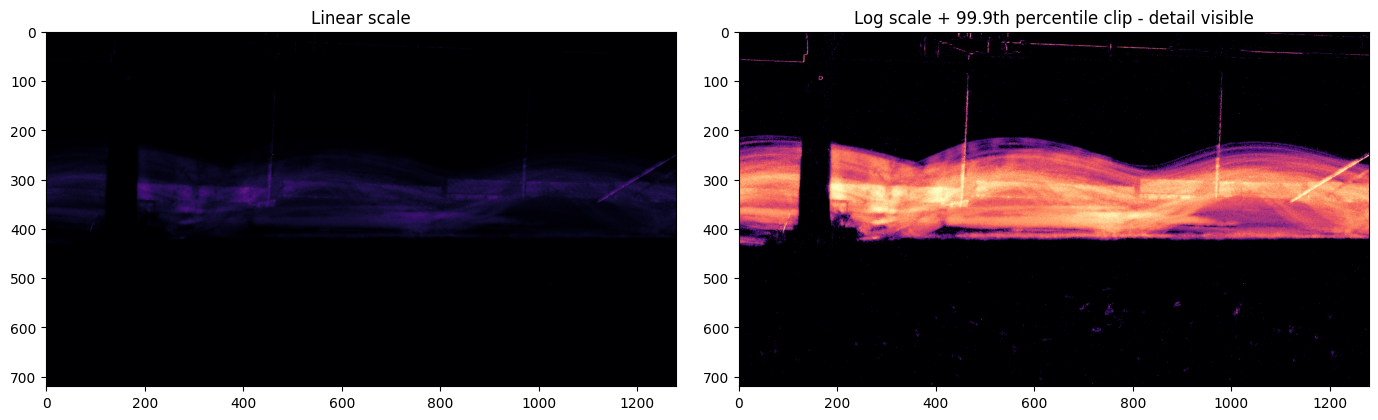

Always use LogNorm when hot pixels are present (star data, low-light, etc.)
The shape of accumulated is: {(720, 1280)}


In [14]:
# ------------------------------------------------------------------
# Tool 1: Accumulated frame with LogNorm to handle hot pixels
# ------------------------------------------------------------------
# import color-handling module of Matplotlib
import matplotlib.colors as mcolors

# Create a 2D NumPy array (a grid) the same size as the sensor resolution
accumulated = np.ones((decoder_es.height, decoder_es.width))

# np.add.at: If multiple events occurred at the same (x, y) coordinate, it adds them all up correctly.
# (decoder_es.height - 1 - events_es['y'], events_es['x']) 
# This tells NumPy exactly where to put the data. It uses a tuple for (Row, Column)
# 1 is the value being added.
# For every event index, add the value 1 to that spot in the accumulated array
np.add.at(accumulated, (decoder_es.height - 1 - events_es['y'], events_es['x']), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(accumulated, cmap='magma')
axes[0].set_title('Linear scale') # this is not the right example - usually hot pixels dominate in linear scale
# I should also add some example to illustrate this in the next tutorials.

#vmax=np.percentile(accumulated, 99.9) - This is a statistical clip. 
# It calculates the value that 99.9% of our pixels fall below. 
# By setting this as the maximum (vmax), we effectively "cutoff" the top 0.1% of the most extreme values (the hot pixels).
# norm=mcolors.LogNorm(...): After clipping the outliers, this scales the remaining data logarithmically.
axes[1].imshow(accumulated, norm=mcolors.LogNorm(vmax=np.percentile(accumulated, 99.9)), cmap='magma')
axes[1].set_title('Log scale + 99.9th percentile clip - detail visible')
plt.tight_layout()
plt.show()
print("Always use LogNorm when hot pixels are present (star data, low-light, etc.)")
print(f"The shape of accumulated is:", {accumulated.shape})


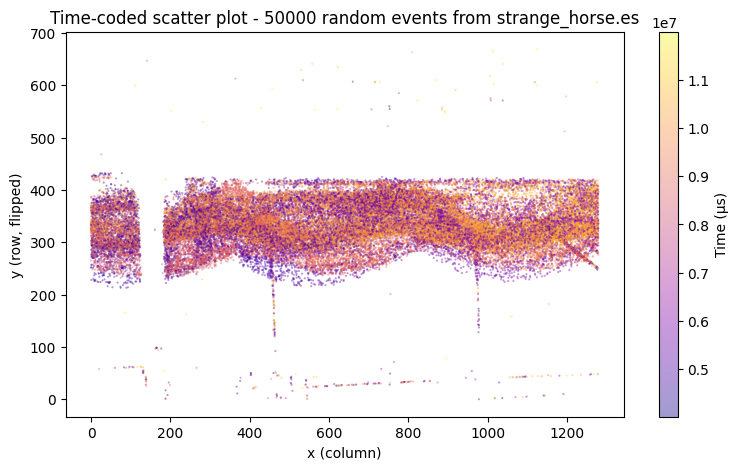

Purple = early events,  Yellow = late events
The direction of colour flow shows the direction of motion in the scene.


In [5]:
# ------------------------------------------------------------------
# Tool 2: Matplotlib animations
# A. Scatter plot coloured by time - see motion direction
# This is especially useful for quick data exploration
# ------------------------------------------------------------------
# Use a random subsample - full data (millions of events) is too slow to scatter-plot
N = 50000
idx = np.random.choice(len(events_es), N, replace=False)
subset = events_es[idx]

plt.figure(figsize=(9, 5))
sc = plt.scatter(
    subset['x'],
    decoder_es.height - 1 - subset['y'],   # flip y to match image convention
    c=subset['t'],
    cmap='plasma',
    s=0.3, alpha=0.4
)
plt.colorbar(sc, label='Time (µs)')
plt.title(f'Time-coded scatter plot - {N} random events from strange_horse.es')
plt.xlabel('x (column)'); plt.ylabel('y (row, flipped)')
plt.show()
print("Purple = early events,  Yellow = late events")
print("The direction of colour flow shows the direction of motion in the scene.")


Frames shape: (10, 2, 720, 1280)


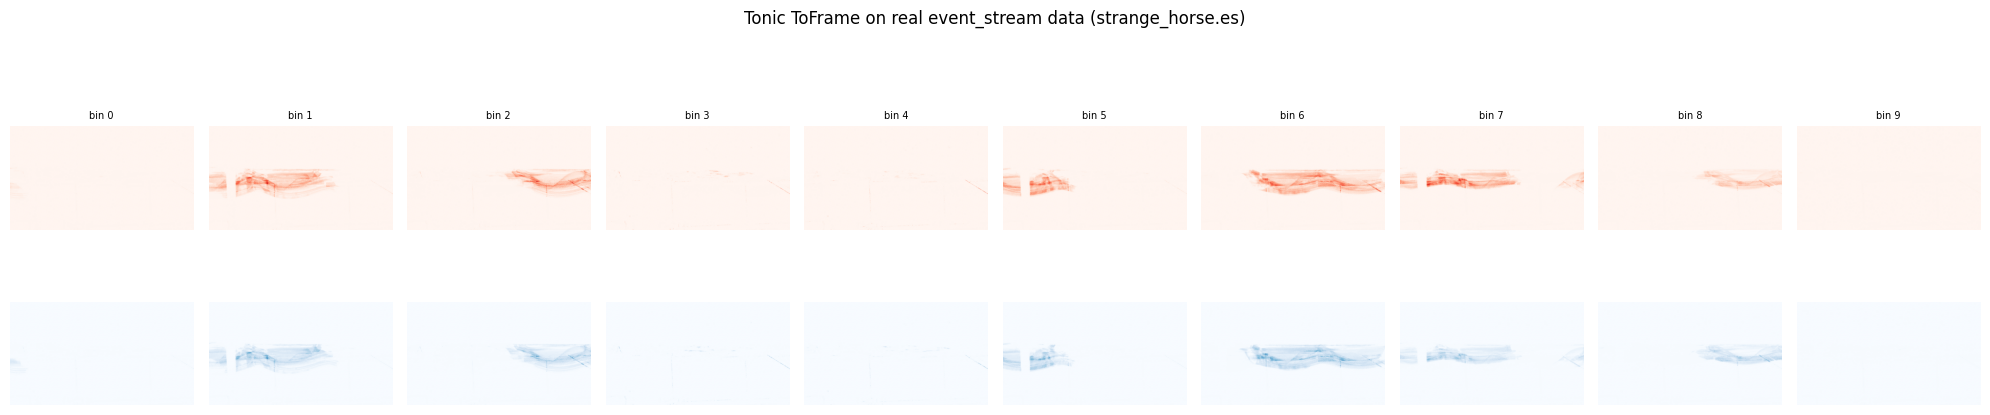


Key insight: tonic transforms work on ANY event data once you match the dtype!


In [6]:
# ------------------------------------------------------------------
# TOOL 3: TONIC ToFrame
# We convert the horse recording into 10 time bins using tonic.
# Use ToFrame to bin events into temporal frames
# ------------------------------------------------------------------
import tonic.transforms as T

# Create a tonic transform - 'ToFrame' bins events into temporal frames
frame_transform = T.ToFrame(sensor_size=sensor_size, n_time_bins=10)

frames_from_real_data = frame_transform(events_tonic_format)
print("Frames shape:", frames_from_real_data.shape)
# shape: [n_time_bins, 2, height, width]

# Visualise the 10 bins
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle("Tonic ToFrame on real event_stream data (strange_horse.es)", fontsize=12)
for t in range(10):
    axes[0, t].imshow(frames_from_real_data[t, 0], cmap='Reds', vmin=0)
    axes[1, t].imshow(frames_from_real_data[t, 1], cmap='Blues', vmin=0)
    axes[0, t].set_title(f'bin {t}', fontsize=7)
    axes[0, t].axis('off')
    axes[1, t].axis('off')
axes[0, 0].set_ylabel('ON', fontsize=9)
axes[1, 0].set_ylabel('OFF', fontsize=9)
plt.tight_layout()
plt.show()
print("\nKey insight: tonic transforms work on ANY event data once you match the dtype!")


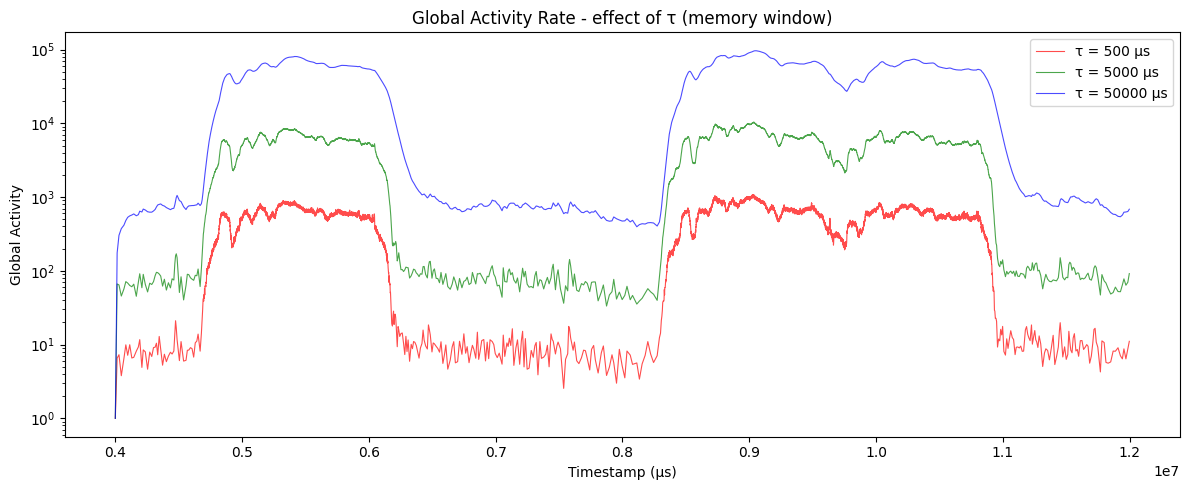

Small τ =Low magnitude, high jitter. Large τ = High magnitude, very smooth.


In [8]:
# ------------------------------------------------------------------
# Tool 4: Leaky Integrator for Event Visualization
# 
# ------------------------------------------------------------------
# Leaky Integrator prioritizes the most recent event 
# Event(activity) exponentially decay over time.
# The leaky integrator solution:
#   activity_new = activity_old * exp(-Δt / τ)   ← LEAK (activity decays)
#                + 1                              ← INTEGRATE (one event arrived)
# Δt is the inter event time interval
# τ (tau) is the "memory window": how quickly old activity is forgotten.
# - Small τ → activity leaks very quickly 
# → By the time the next event arrives, the previous one is already gone → lower counts 
# - Large τ → long memory   → activity leaks very slowly → events stack on top of each other
# Acts as RC Low-Pass Filter for event data
# Large τ : Results in a low cutoff frequency. 
# It blocks the "high-frequency" jitter (noise) and only lets the slow, smooth movements through.
# Small τ : Results in a high cutoff frequency. 
# It lets the fast, rapid changes through but keeps the signal very "noisy."

import math

tau_values = [500, 5000, 50000]       # microseconds
colors     = ['red', 'green', 'blue']

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlabel('Timestamp (µs)')
ax.set_ylabel('Global Activity')
ax.set_title('Global Activity Rate - effect of τ (memory window)')

for tau, color in zip(tau_values, colors):
    decoder_act = event_stream.Decoder(f"{DATA_DIR}/strange_horse.es")
    activity = 0.0
    prev_t   = None       # ← initialise as None, set on first event

    ts_list  = []
    act_list = []

    for packet in decoder_act:
        for t, x, y, p in packet:
            # Cast BOTH to float before subtracting.
            # Without this: t is numpy uint64, -dt wraps around to ~1.8×10^19
            # and math.exp(+1.8e19 / tau) raises OverflowError.
            t_f = float(t)

            if prev_t is None:
                prev_t = t_f          # skip decay on the very first event
                dt = 0.0
            else:
                dt = t_f - prev_t     # guaranteed non-negative Python float

            activity *= math.exp(-dt / tau)   # leak:      always exp(≤ 0)
            activity += 1                     # integrate: +1 per event
            prev_t = t_f

            ts_list.append(t_f)
            act_list.append(activity)

    ax.plot(ts_list[::200], act_list[::200], color=color, alpha=0.7,
            linewidth=0.8, label=f'τ = {tau} µs')

ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("Small τ =Low magnitude, high jitter. Large τ = High magnitude, very smooth.")


---
## 4. Generating Frames from Event-Based Data

Generating frames from event-based camera data is important in the context of gaining intuition and for interpretability of the data (say in the context of bug fixing).

### The algorithm
1. Choose a **frame duration** Δt (in µs).
2. Scan through all events. When `t ≥ next_frame_boundary`, start a new frame.
3. Within each frame, record which pixels fired and their polarity.
4. Collect all frames into a list for animation.

### Key design decision: what to write to each pixel?
The AMOS Tutorial 1 approach is to write `+1` for ON, `-1` for OFF.
This means the frame represents the **last event** at each pixel.
We will explore two alternatives in Sections 5 and 6.

### The parametric experiment
Frame duration is a crucial parameter.
- **Too long**: many events pile up → motion blurs into a smear, temporal detail lost
- **Too short**: very few events per frame → noisy, sparse, object barely visible

Let's run a parametric experiment to see this effect.


In [ ]:
# ------------------------------------------------------------------
# Base frame generation function (AMOS Tutorial 1 approach, generalised)
# ------------------------------------------------------------------

def generate_frames_basic(events, width, height, frame_duration_us):
    """
    Convert an event array into a list of frames.

    Each pixel stores the polarity (+1 or -1) of the LAST event
    within that frame's time window.  Pixels with no events stay 0.

    Parameters
    ----------
    events          : numpy structured array with fields 'x', 'y', 't', 'on'
    width, height   : sensor dimensions (pixels)
    frame_duration_us : frame duration in microseconds

    Returns
    -------
    frames : list of 2D numpy arrays, shape (height, width)
    """
    frames = []
    frame  = np.zeros((height, width), dtype=np.float32)
    next_frame_t = int(events['t'][0]) + frame_duration_us

    for t, x, y, on in events:
        if t >= next_frame_t:
            frames.append(frame.copy())
            frame[:] = 0                      # reset frame
            next_frame_t += frame_duration_us
        # Write polarity to the pixel — last event wins
        frame[height - 1 - y, x] = 1.0 if on else -1.0

    if frame.any():                           # don't lose the last partial frame
        frames.append(frame.copy())

    return frames

# Load the two-horses dataset (smaller file — good for testing)
decoder_2h = event_stream.Decoder(f"{DATA_DIR}/two_horses.es")
events_2h  = np.concatenate(list(decoder_2h))
W, H = decoder_2h.width, decoder_2h.height

print(f"Loaded two_horses.es: {len(events_2h):,} events")
print(f"Duration: {(events_2h['t'][-1] - events_2h['t'][0]) / 1e6:.2f} seconds")
print(f"Sensor: {W} x {H} pixels")


In [ ]:
# ------------------------------------------------------------------
# Parametric experiment: vary frame duration across one order of magnitude
# ------------------------------------------------------------------

FRAME_DURATIONS = [5_000, 20_000, 50_000, 100_000, 500_000]  # µs

fig, axes = plt.subplots(len(FRAME_DURATIONS), 4, figsize=(14, 3 * len(FRAME_DURATIONS)))
fig.suptitle('Frame Duration Experiment — two_horses.es\n'
             'Each row is a different frame duration; columns show 4 consecutive frames',
             fontsize=11)

for row, dur in enumerate(FRAME_DURATIONS):
    frames = generate_frames_basic(events_2h, W, H, dur)
    n_frames = len(frames)

    # Pick 4 frames evenly spaced through the recording
    idxs = [int(n_frames * f) for f in [0.2, 0.4, 0.6, 0.8]]

    for col, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(frames[min(idx, n_frames-1)], cmap='RdBu', vmin=-1, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'{dur//1000} ms', fontsize=9, rotation=90)
        ax.set_title(f'frame {idx}', fontsize=7)

plt.tight_layout()
plt.savefig('./data/frame_duration_experiment.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nSaved to ./data/frame_duration_experiment.png")
print("\nObservations to look for:")
print("  5 ms  → very sparse, barely any events per frame, noisy")
print("  20 ms → good balance of motion detail vs. signal density")
print("  50 ms → motion trails starting to appear for fast objects")
print("  100 ms → clear motion blur, edges smear")
print("  500 ms → very blurry, object trajectory visible as a streak")


In [ ]:
# ------------------------------------------------------------------
# Summary statistics across frame durations
# ------------------------------------------------------------------

print(f"{'Duration':>12}  {'Num Frames':>10}  {'Avg Events/Frame':>17}  {'Non-zero px %':>14}")
print("-" * 60)

total_events = len(events_2h)

for dur in FRAME_DURATIONS:
    frames = generate_frames_basic(events_2h, W, H, dur)
    n = len(frames)
    avg_events = total_events / n if n > 0 else 0
    # average fraction of non-zero pixels across all frames
    nonzero_pct = np.mean([np.count_nonzero(f) / (W * H) * 100 for f in frames])
    print(f"{dur//1000:>9} ms  {n:>10,}  {avg_events:>17.0f}  {nonzero_pct:>13.1f}%")

print("\nKey insight: shorter frames → more frames, fewer events per frame, sparser.")
print("There is a trade-off between temporal resolution and spatial density.")


---
## 5. Blending the Current Frame with a Weighted Previous Frame

The basic method above has a problem: very sparse frames look 'noisy' because
each frame only shows events from a short window.

**Exponential temporal blending** solves this by keeping a 'memory' of past frames.
Each new frame is blended with a decayed version of the previous frame:

```
blended_frame = α × current_frame + (1 - α) × previous_blended_frame
```

Where:
- `α = 1` → no memory (identical to the basic method)
- `α = 0` → pure memory (the frame never updates — not useful)
- `α ≈ 0.3–0.7` → good balance; old events fade out, new events are bright

This is analogous to a long-exposure photograph where older light fades.
It is also related to the **time surface** representation used in many event-based
computer vision papers.

### Why this matters for SNNs

The blended frame is a smooth representation that a convolutional SNN layer
can process. The exponential decay mirrors the **membrane potential decay** in a
leaky integrate-and-fire neuron. This connection is not coincidental — both use
the same mathematical form (`e^(-t/τ)`) to encode temporal proximity.


In [ ]:
# ------------------------------------------------------------------
# Blended frame generation
# ------------------------------------------------------------------

def generate_frames_blended(events, width, height, frame_duration_us, alpha=0.4):
    """
    Generate frames with temporal blending.

    current_events is written into the frame as before (+1 / -1).
    The result is then blended with the previous frame:

        blended = alpha * current_raw + (1 - alpha) * prev_blended

    Parameters
    ----------
    alpha : float in (0, 1]
        Blending coefficient. 1.0 = no blending (basic method).
        Lower values give longer temporal memory / smoother output.
    """
    frames     = []
    raw_frame  = np.zeros((height, width), dtype=np.float32)  # current events
    blended    = np.zeros((height, width), dtype=np.float32)  # blended output
    next_frame_t = int(events['t'][0]) + frame_duration_us

    for t, x, y, on in events:
        if t >= next_frame_t:
            # 1. Blend: new = alpha * raw + (1 - alpha) * previous_blended
            blended = alpha * raw_frame + (1.0 - alpha) * blended
            frames.append(blended.copy())
            raw_frame[:] = 0                  # reset raw event accumulator
            next_frame_t += frame_duration_us
        raw_frame[height - 1 - y, x] = 1.0 if on else -1.0

    return frames

# Compare alpha values at a fixed 20 ms frame duration
ALPHAS = [1.0, 0.7, 0.4, 0.2, 0.05]
FRAME_DUR = 20_000   # 20 ms

fig, axes = plt.subplots(len(ALPHAS), 4, figsize=(14, 3 * len(ALPHAS)))
fig.suptitle('Blending Experiment — α controls temporal memory\n'
             'α=1.0 is the unblended baseline; smaller α = longer memory',
             fontsize=11)

for row, alpha in enumerate(ALPHAS):
    frames = generate_frames_blended(events_2h, W, H, FRAME_DUR, alpha=alpha)
    n = len(frames)
    idxs = [int(n * f) for f in [0.2, 0.4, 0.6, 0.8]]
    for col, idx in enumerate(idxs):
        ax = axes[row, col]
        ax.imshow(frames[min(idx, n-1)], cmap='RdBu', vmin=-1, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f'α={alpha}', fontsize=9)
        ax.set_title(f'frame {idx}', fontsize=7)

plt.tight_layout()
plt.savefig('./data/blending_experiment.png', dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Create an animation of the blended version to see the motion trail effect
# The 'motion trail' effect is visually very similar to what your eye does
# when tracking a fast-moving object.
# ------------------------------------------------------------------
%matplotlib inline

FRAME_DUR = 10_000   # 10 ms frames
ALPHA     = 0.3      # strong blending → visible trails

frames_blended  = generate_frames_blended(events_2h, W, H, FRAME_DUR, alpha=ALPHA)
frames_basic    = generate_frames_basic(events_2h, W, H, FRAME_DUR)

print(f"Generated {len(frames_blended)} frames at 10 ms duration")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'Basic (α=1.0) vs Blended (α={ALPHA}) — 10 ms frames')

img1 = ax1.imshow(frames_basic[0],   cmap='RdBu', vmin=-1, vmax=1)
ax1.set_title('Basic (no memory)')
ax1.axis('off')

img2 = ax2.imshow(frames_blended[0], cmap='RdBu', vmin=-1, vmax=1)
ax2.set_title(f'Blended (α={ALPHA})')
ax2.axis('off')

def animate(i):
    img1.set_data(frames_basic[i])
    img2.set_data(frames_blended[i])
    return img1, img2

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=min(100, len(frames_blended)),
                                          interval=50, blit=True)
HTML(ani.to_jshtml())


---
## 6. Alternative Frame Conversion: Counting Events at Each Pixel

So far, each pixel in a frame stores the polarity of the **last** event.
But this throws away information — if a pixel fires 5 times in a window,
we see the same `+1` as if it fired once.

### Event count representation

Instead, we count how many events (or ON/OFF events separately) occurred
at each pixel within the time window.

- A pixel with count 0 had no activity
- A pixel with count 5 fired 5 times — it is a high-activity pixel

This naturally handles intensity: pixels at object edges generate many events
(the edge contrast triggers repeating ON/OFF events as the object moves);
background static pixels generate almost nothing.

### Comparison of representations

| Representation | Pixel value | Information kept | Best for |
|---|---|---|---|
| Last polarity | −1, 0, +1 | Polarity only | Quick visualisation |
| ON count | 0, 1, 2, … | ON intensity | Texture, edges |
| OFF count | 0, 1, 2, … | OFF intensity | Texture, edges |
| Net count | −N, …, +N | Dominant polarity + magnitude | Motion direction |
| Total count | 0, 1, 2, … | Activity level | Noise detection |


In [ ]:
# ------------------------------------------------------------------
# Event-count frame generation
# ------------------------------------------------------------------

def generate_frames_count(events, width, height, frame_duration_us, mode='total'):
    """
    Generate frames by counting events per pixel per time window.

    Parameters
    ----------
    mode : str
        'on'    → count only ON events
        'off'   → count only OFF events
        'net'   → ON_count − OFF_count  (can be negative)
        'total' → ON_count + OFF_count  (always ≥ 0)
    """
    frames = []
    on_frame  = np.zeros((height, width), dtype=np.float32)
    off_frame = np.zeros((height, width), dtype=np.float32)
    next_frame_t = int(events['t'][0]) + frame_duration_us

    for t, x, y, on in events:
        if t >= next_frame_t:
            if   mode == 'on':    frames.append(on_frame.copy())
            elif mode == 'off':   frames.append(off_frame.copy())
            elif mode == 'net':   frames.append((on_frame - off_frame).copy())
            else:                 frames.append((on_frame + off_frame).copy())   # total
            on_frame[:]  = 0
            off_frame[:] = 0
            next_frame_t += frame_duration_us
        y_flipped = height - 1 - y
        if on:
            on_frame[y_flipped, x]  += 1
        else:
            off_frame[y_flipped, x] += 1

    return frames

# Generate all four modes at 20 ms
FRAME_DUR = 20_000

frames_on    = generate_frames_count(events_2h, W, H, FRAME_DUR, mode='on')
frames_off   = generate_frames_count(events_2h, W, H, FRAME_DUR, mode='off')
frames_net   = generate_frames_count(events_2h, W, H, FRAME_DUR, mode='net')
frames_total = generate_frames_count(events_2h, W, H, FRAME_DUR, mode='total')

# Show frame 30 from each mode
IDX = 30
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['ON count', 'OFF count', 'Net (ON − OFF)', 'Total (ON + OFF)']
cmaps  = ['Reds',      'Blues',    'RdBu',            'viridis']
fdata  = [frames_on[IDX], frames_off[IDX], frames_net[IDX], frames_total[IDX]]

for ax, data, title, cmap in zip(axes, fdata, titles, cmaps):
    vmax = max(data.max(), 1)
    vmin = -vmax if cmap == 'RdBu' else 0
    ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.suptitle(f'Event-count representations — frame {IDX} of two_horses.es', fontsize=11)
plt.tight_layout()
plt.savefig('./data/event_count_representations.png', dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
# ------------------------------------------------------------------
# Quantitative comparison: how much information do we keep?
# We measure the signal in a few pixels with known activity.
# ------------------------------------------------------------------

frame_idx = 40   # pick a frame with visible horse motion

basic   = generate_frames_basic(events_2h, W, H, FRAME_DUR)[frame_idx]
total_c = frames_total[frame_idx]
net_c   = frames_net[frame_idx]

# Find the top-10 most active pixels in the total-count frame
flat_idx = np.argsort(total_c.ravel())[::-1][:10]
rows, cols = np.unravel_index(flat_idx, total_c.shape)

print("Top-10 most active pixels (by total event count):")
print(f"{'Row':>5} {'Col':>5}  {'Basic':>7}  {'Total':>7}  {'Net':>7}")
print("-" * 40)
for r, c in zip(rows, cols):
    print(f"{r:>5} {c:>5}  {basic[r,c]:>7.1f}  {total_c[r,c]:>7.0f}  {net_c[r,c]:>7.0f}")

print("\nInsight: 'Basic' shows only ±1. 'Total' reveals that some pixels fired many")
print("times in this window. 'Net' shows whether the pixel was more ON or OFF overall.")


In [ ]:
# ------------------------------------------------------------------
# Final visualisation: animate total-count vs blended side by side
# Use 'hot' colormap for count data (like thermal camera)
# ------------------------------------------------------------------
%matplotlib inline

FRAME_DUR = 15_000   # 15 ms
ALPHA     = 0.35

frames_tc = generate_frames_count(events_2h, W, H, FRAME_DUR, mode='total')
frames_bl = generate_frames_blended(events_2h, W, H, FRAME_DUR, alpha=ALPHA)

N = min(80, len(frames_tc), len(frames_bl))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Total-count vs Blended Polarity — 15 ms frames')
img1 = ax1.imshow(frames_tc[0], cmap='hot', vmin=0, vmax=5)
ax1.set_title('Total event count'); ax1.axis('off')
img2 = ax2.imshow(frames_bl[0],  cmap='RdBu', vmin=-1, vmax=1)
ax2.set_title(f'Blended (α={ALPHA})'); ax2.axis('off')

def animate2(i):
    img1.set_data(frames_tc[i])
    img2.set_data(frames_bl[i])

ani2 = matplotlib.animation.FuncAnimation(fig, animate2, frames=N, interval=50, blit=False)
HTML(ani2.to_jshtml())


---
## Summary — Part 1

**What we covered:**

1. **`tonic` vs `event_stream`**: tonic = benchmark datasets + rich transforms; event_stream = raw camera files. Same (x, y, t, p) data structure. Use tonic transforms on event_stream data with a simple dtype conversion helper.

2. **Visualisation tools**: accumulated frames (with LogNorm for hot pixels), time-coded scatter plots, polarity-split plots, global activity rate (leaky integrator = LIF neuron without threshold).

3. **Frame generation parametric experiment**: frame duration controls the temporal resolution / spatial density trade-off. 5–20 ms works well for moderate motion; 100+ ms causes motion blur.

4. **Temporal blending** (`α` parameter): adds exponential memory so sparse frames look smoother. Smaller α = longer memory = motion trails. Mathematically equivalent to membrane potential decay in a LIF neuron.

5. **Event-count representations**: instead of last-polarity (±1), count ON, OFF, net, or total events per pixel. Reveals activity magnitude that the last-polarity method discards.

---

**Next**: Part 2 covers **noise filtering** — implementing and comparing neighbourhood-support filters of increasing kernel size, and exploring multi-pixel support thresholds.
